In [1]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import DataLoader

import numpy as np
import sklearn
from sklearn import preprocessing, metrics, calibration
from tqdm.notebook import tqdm
import types
import copy

import matplotlib
import matplotlib.pyplot as plt

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import utils
import utils.Camel.equations as equations

from utils.plotting import get_scores, get_r_hats
from evaluation_helpers import plot_closure

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/test/QuasiDRE/ToyModels/../utils/__init__.py:4: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  from . import plotting


In [2]:
SAVE_DIR = "./models"
DATA_DIR = "./data"

In [3]:
source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)

source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
target_file = osp.join(DATA_DIR, "target_distribution_mc_data")


STOP_EVENT = int(np.min((np.load(source_file + "_test.npy").shape[0], np.load(target_file + "_test.npy").shape[0])))
test_base_dataset = utils.preprocessing.Dataset(source_file + "_test.npy", 0, stop_event=STOP_EVENT)
test_target_dataset = utils.preprocessing.Dataset(target_file + "_test.npy", 1, stop_event=STOP_EVENT)

test_base_dataset.process(normalize_weights=True)
test_target_dataset.process(normalize_weights=True)

test_generator_data = utils.preprocessing.CombinedDataset(test_base_dataset, test_target_dataset)
print(len(test_generator_data))

test_loader = DataLoader(test_generator_data, batch_size=int(2**10), shuffle=False)
test_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(test_base_dataset), batch_size=int(2**10), shuffle=False)
test_target_loader = DataLoader(utils.preprocessing.CombinedDataset(test_target_dataset), batch_size=int(2**10), shuffle=False)

2800000


In [4]:
# Get the analytical optimal classifier
s_optimal = equations.optimal_binary_classifier(source_mixture_coef, source_scales, target_mixture_coef, target_scales)

# Load the best models

## Load the SMM model

In [17]:
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_SMM_batch{}.zip".format(batch_size))
SMM_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMM, weight_norm_SMM = utils.preprocessing.load_scaling(modpath)
SMM_model.coefficients

(1.3322486877441406, 1.995090126991272)

In [18]:
print(SMM_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the $\textrm{SMM}_c$ model

In [ ]:
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_SMMc_revert_batch{}.zip".format(batch_size))
SMMc_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMMc, weight_norm_SMMc = utils.preprocessing.load_scaling(modpath)
SMMc_model.coefficients

(1.1055060625076294, 1.9824146032333374)

In [8]:
print(SMMc_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the $\textrm{SMM}_r$ model

In [9]:
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_SMMr_revert_batch{}.zip".format(batch_size))
SMMr_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMMr, weight_norm_SMMr = utils.preprocessing.load_scaling(modpath)
SMMr_model.coefficients

(1.270193338394165, 1.9948434829711914)

In [10]:
print(SMMr_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the REVERT classifier

In [14]:
LOSS = "revert"
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_{}_batch{}.zip".format(LOSS, batch_size))
revert_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_revert, weight_norm_revert = utils.preprocessing.load_scaling(modpath)

In [15]:
print(revert_model)

Classifier(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


# Evaluate the models

## Look at reweighting closure metrics

In [23]:
model_names = ["MLP REVERT", "RoSMM", "RoSMM-c REVERT", "RoSMM-r REVERT", "Optimal"]
models = [revert_model, SMM_model, SMMc_model, SMMr_model, s_optimal]
X_scalers = [X_scaler_revert, X_scaler_SMM, X_scaler_SMMc, X_scaler_SMMr, None]
weight_norms = [weight_norm_revert, weight_norm_SMM, weight_norm_SMMc, weight_norm_SMMr, 1.0]

In [24]:
r_hats_list = []
for i in range(len(models)):
    loss = "revert" if "REVERT" in model_names[i] else "pare" if "PARE" in model_names[i] else "bce"
    mix = True if "SMM" in model_names[i] else False
    r_hat = get_r_hats(
        models[i],
        test_nominal_loader,
        X_scaler=X_scalers[i],
        weight_norm=weight_norms[i],
        loss=loss,
        mix=mix,
        leave=True,
        device=DEVICE
    )
    r_hats_list.append(r_hat)

100%|██████████| 1368/1368 [00:06<00:00, 198.74it/s]


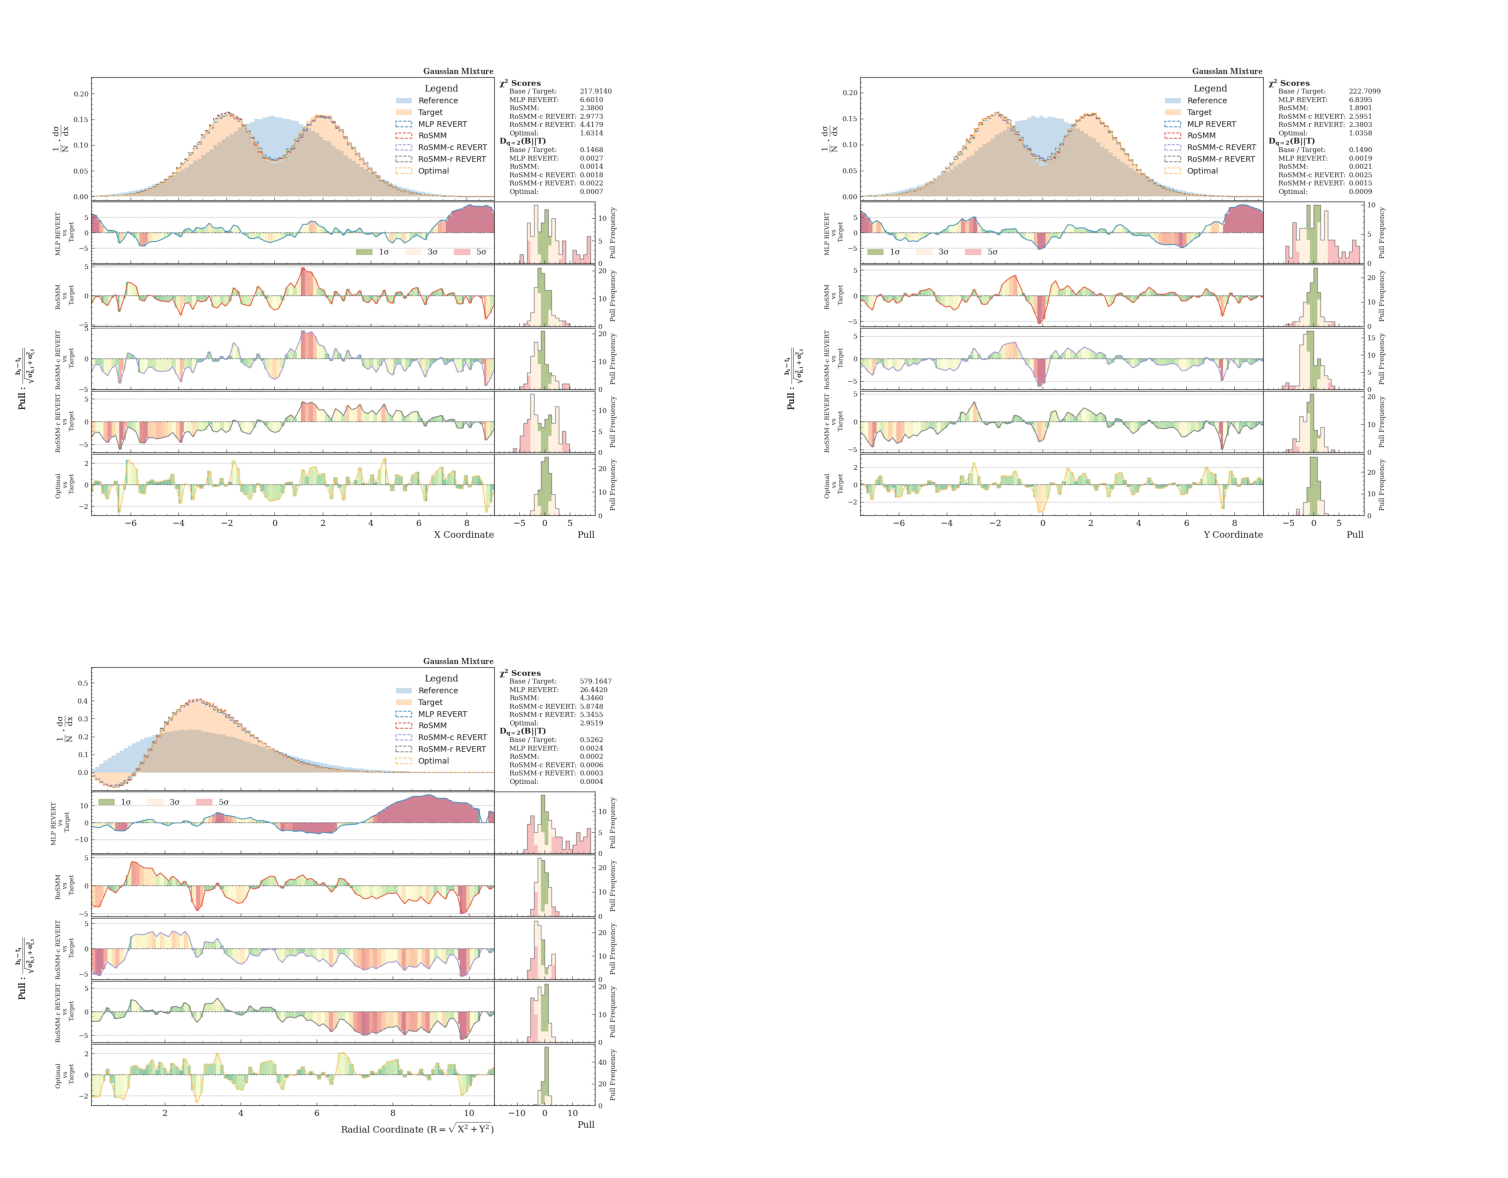

['/tmp/tmpy07x2ram/ToyModel_subdensity_0_tmp.png',
 '/tmp/tmpy07x2ram/ToyModel_subdensity_1_tmp.png',
 '/tmp/tmpy07x2ram/ToyModel_subdensity_2_tmp.png']

In [33]:
kwargs={'legend.title_fontsize': 16, 'legend.fontsize': 14, 'table.fontsize': 12,
        'font.size': 14, 'axes.titlesize':20, 'axes.labelsize':16,'figure.titlesize':20, 'ytick.labelsize':12, 'figure.figsize':(16,14)}

plot_closure(r_hats_list, test_nominal_loader, test_target_loader, "Reference", "Target", carl_names=model_names, percentile_cuts=(0.1, 99.99), kwargs_plot=kwargs)